In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving COALINDIA.csv to COALINDIA.csv


In [3]:
df = pd.read_csv("COALINDIA.csv")

df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2010-11-04,COALINDIA,EQ,245.00,291.00,344.9,291.00,342.0,342.55,327.29,479716245,1.570040e+16,NaN,187584905,0.3910
1,2010-11-05,COALINDIA,EQ,342.55,343.00,356.5,343.00,348.3,349.85,349.78,31927173,1.116747e+15,NaN,10894509,0.3412
2,2010-11-08,COALINDIA,EQ,349.85,351.80,355.9,329.50,331.4,330.75,335.19,46932779,1.573118e+15,NaN,16651623,0.3548
3,2010-11-09,COALINDIA,EQ,330.75,330.15,333.4,325.00,325.4,326.05,327.75,23741956,7.781383e+14,NaN,12977359,0.5466
4,2010-11-10,COALINDIA,EQ,326.05,325.40,327.8,320.05,321.3,322.80,323.78,21057129,6.817982e+14,NaN,6280335,0.2983


In [4]:
print(df.shape)

print(df.columns)

df.info()

(2598, 15)
Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2598 entries, 0 to 2597
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                2598 non-null   object 
 1   Symbol              2598 non-null   object 
 2   Series              2598 non-null   object 
 3   Prev Close          2598 non-null   float64
 4   Open                2598 non-null   float64
 5   High                2598 non-null   float64
 6   Low                 2598 non-null   float64
 7   Last                2598 non-null   float64
 8   Close               2598 non-null   float64
 9   VWAP                2598 non-null   float64
 10  Volume              2598 non-null   int64  
 11  Turnover            2598 non-null   f

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df = df[
    [
        'Date',
        'Open',
        'High',
        'Low',
        'Close',
        'Volume'
    ]
]

df.dropna(inplace=True)

df.head()

,Date,Open,High,Low,Close,Volume
0,2010-11-04,291.00,344.9,291.00,342.55,479716245
1,2010-11-05,343.00,356.5,343.00,349.85,31927173
2,2010-11-08,351.80,355.9,329.50,330.75,46932779
3,2010-11-09,330.15,333.4,325.00,326.05,23741956
4,2010-11-10,325.40,327.8,320.05,322.80,21057129


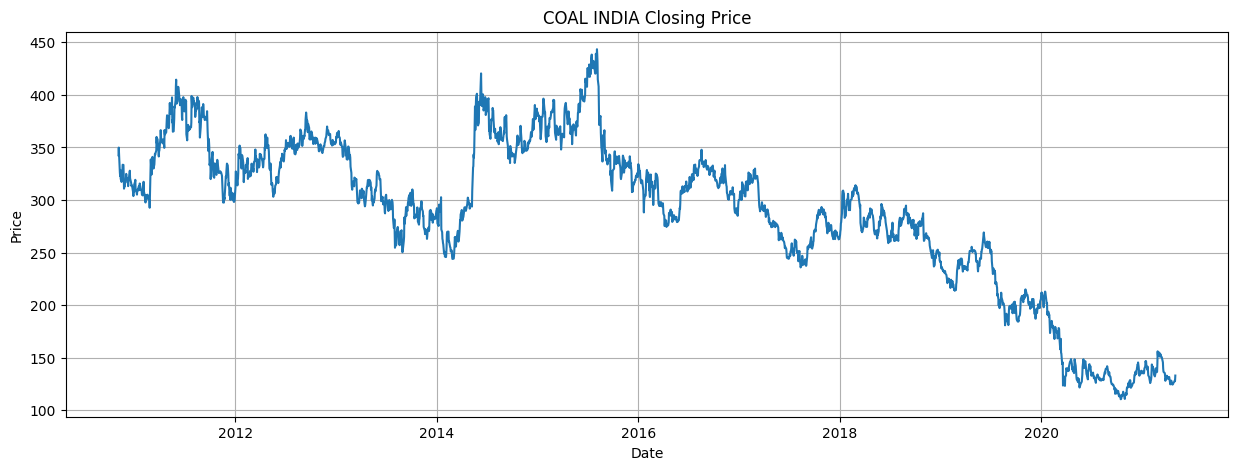

In [6]:
plt.figure(figsize=(15,5))

plt.plot(df['Date'], df['Close'])

plt.title("COAL INDIA Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.grid(True)

plt.show()

In [8]:
# Daily Return

df['Daily_Return'] = df['Close'].pct_change()

# Price Change

df['Price_Change'] = df['Close'] - df['Open']

# Daily Volatility

df['High_Low_Diff'] = df['High'] - df['Low']

# Volume Change

df['Volume_Change'] = df['Volume'].pct_change()

# Moving Average

df['MA20'] = df['Close'].rolling(20).mean()

# Volatility

df['Volatility'] = df['Daily_Return'].rolling(20).std()

In [9]:
df['Target'] = (
    df['Close'].shift(-1) > df['Close']
).astype(int)

In [10]:
df.dropna(inplace=True)

df.head()

,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Change,High_Low_Diff,Volume_Change,MA20,Volatility,Target
20,2010-12-03,318.1,325.70,318.10,321.95,2453815,-0.008927,3.85,7.60,-0.600573,323.3250,0.021643,0
21,2010-12-06,321.0,324.90,318.50,320.40,2895539,-0.004814,-0.60,6.40,0.180015,321.8525,0.020882,0
22,2010-12-07,320.5,322.75,317.25,320.00,3484977,-0.001248,-0.50,5.50,0.203568,321.3150,0.017183,0
23,2010-12-08,318.6,322.70,317.25,318.85,2877153,-0.003594,0.25,5.45,-0.174413,320.9550,0.016932,0
24,2010-12-09,318.0,320.00,309.00,313.20,5313081,-0.017720,-4.80,11.00,0.846645,320.4750,0.017234,1


In [12]:
features = [
    'Daily_Return',
    'Price_Change',
    'High_Low_Diff',
    'Volume_Change',
    'MA20',
    'Volatility'
]

X = df[features]

y = df['Target']

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    random_state=42
)

In [15]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [16]:
y_pred = model.predict(X_test)

In [17]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

Accuracy : 0.5038759689922481
Precision: 0.4746666666666667
Recall   : 0.4876712328767123
F1 Score : 0.4810810810810811


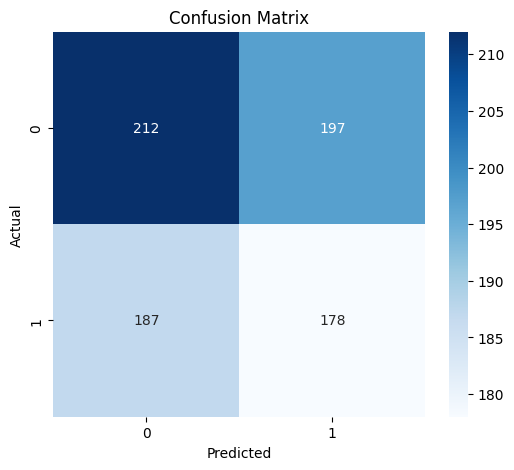

In [18]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

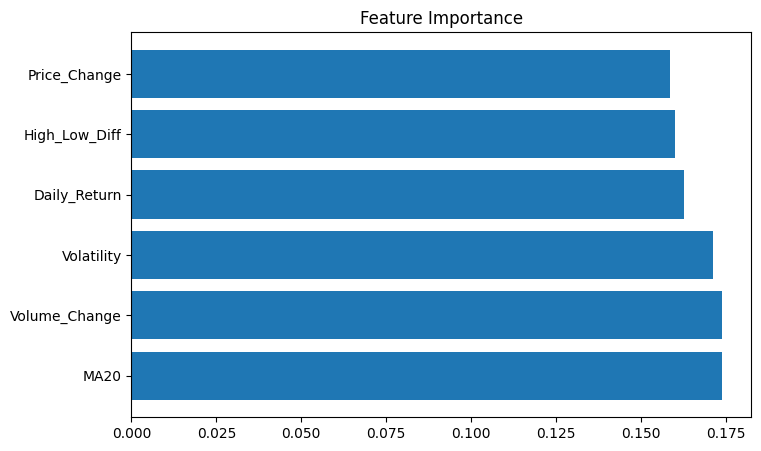

In [19]:
importances = model.feature_importances_

feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    feature_df['Feature'],
    feature_df['Importance']
)

plt.title("Feature Importance")

plt.show()

In [20]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.53      0.52      0.52       409
           1       0.47      0.49      0.48       365

    accuracy                           0.50       774
   macro avg       0.50      0.50      0.50       774
weighted avg       0.50      0.50      0.50       774

